Simulation Setting
dT = 0.1 s
t_end = 30.0 s
N = 301


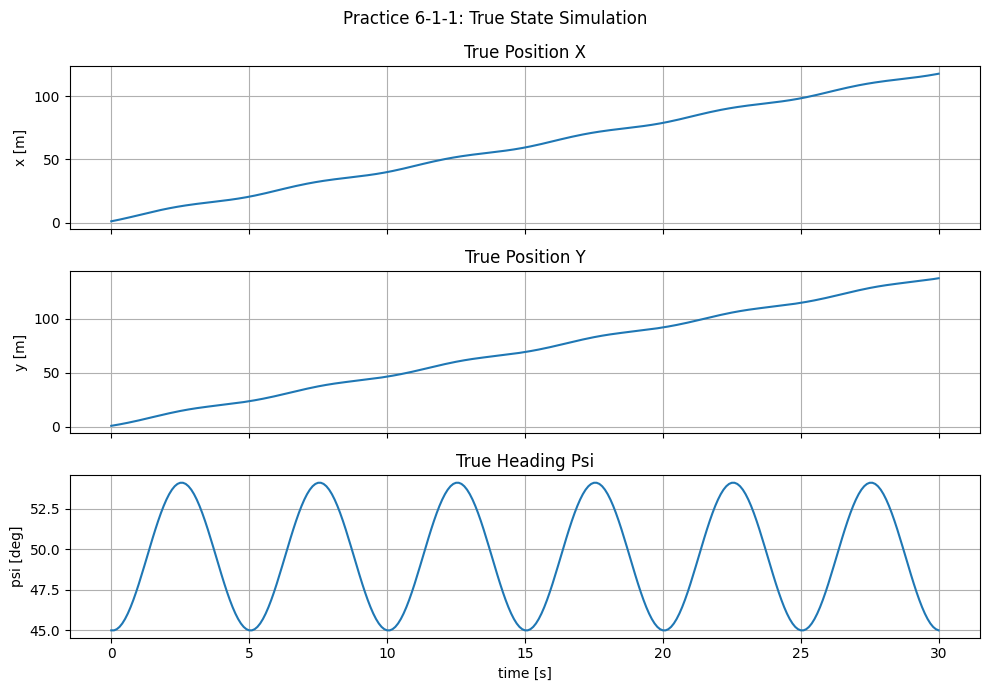

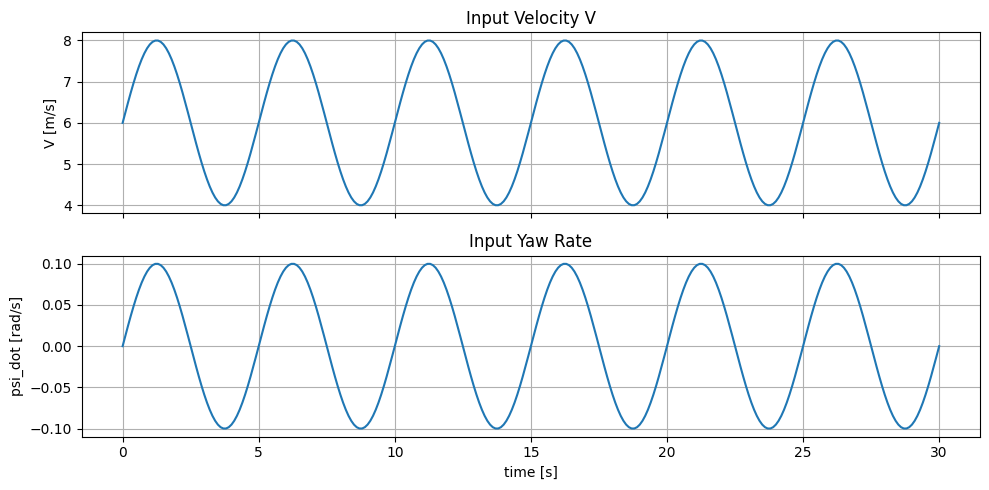

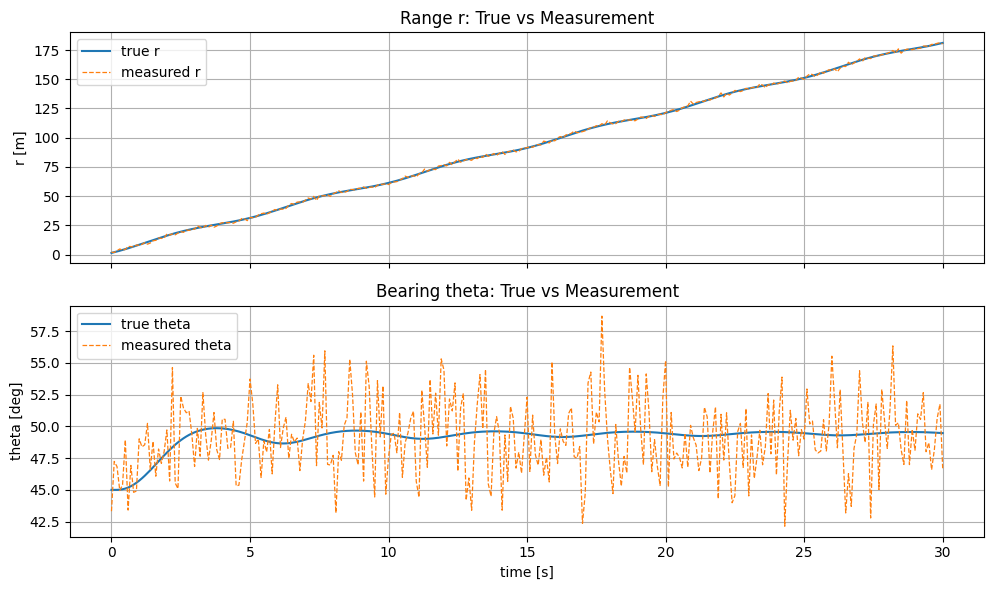

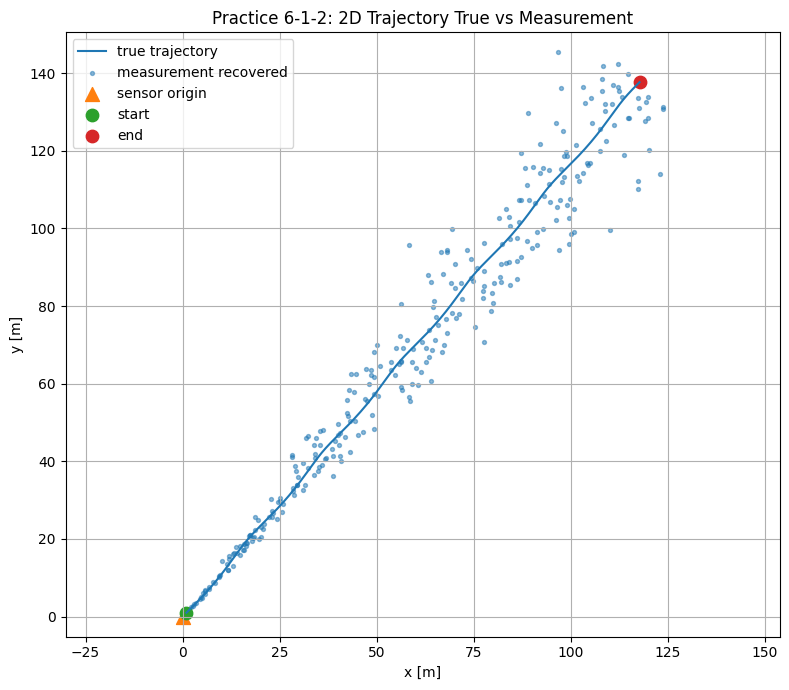

Part 1 Result Check
x_history shape       : (301, 3)
y_history shape       : (301, 2)
sigma_r               : 1.0000 m
sigma_theta           : 3.0000 deg
noise_r mean          : -0.0083
noise_r std           : 0.9821
noise_theta mean      : -0.0576 deg
noise_theta std       : 2.8792 deg


In [2]:
# ============================================================
# Practice 6 - Part 1
# True State and Measurement Simulation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1️⃣ 기본 함수 정의
# ============================================================

def wrap_angle(angle):
    """
    angle을 -pi ~ pi 범위로 변환
    """
    return (angle + np.pi) % (2 * np.pi) - np.pi


# ============================================================
# 2️⃣ 시뮬레이션 조건 설정
# ============================================================

dT     = 0.1
t_end  = 30.0
t      = np.arange(0.0, t_end + dT, dT)
N      = len(t)

print("=" * 60)
print("Simulation Setting")
print("=" * 60)
print(f"dT = {dT} s")
print(f"t_end = {t_end} s")
print(f"N = {N}")
print("=" * 60)


# ============================================================
# 3️⃣ 입력 데이터 생성
#    V       : velocity input
#    psi_dot : yaw rate input
# ============================================================

V = 6.0 + 2.0 * np.sin(2.0 * np.pi * t / 5.0)
psi_dot = 0.1 * np.sin(2.0 * np.pi * t / 5.0)


# ============================================================
# 4️⃣ True State Simulation
#    State = [x, y, psi]^T
# ============================================================

x_history = np.zeros((N, 3))

x_history[0, 0] = 1.0
x_history[0, 1] = 1.0
x_history[0, 2] = np.deg2rad(45.0)

for k in range(1, N):
    x_prev   = x_history[k - 1, 0]
    y_prev   = x_history[k - 1, 1]
    psi_prev = x_history[k - 1, 2]

    V_prev       = V[k - 1]
    psi_dot_prev = psi_dot[k - 1]

    x_new   = x_prev + V_prev * dT * np.cos(psi_prev)
    y_new   = y_prev + V_prev * dT * np.sin(psi_prev)
    psi_new = psi_prev + psi_dot_prev * dT

    x_history[k, 0] = x_new
    x_history[k, 1] = y_new
    x_history[k, 2] = wrap_angle(psi_new)


# ============================================================
# 5️⃣ Bearing Sensor Measurement Function
#    h(x) = [r, theta]^T
# ============================================================

def h_bearing_xy(x, y):
    """
    input:
        x, y

    output:
        [range, bearing angle]
    """
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    return np.array([r, theta])


# ============================================================
# 6️⃣ Measurement Noise 설정
# ============================================================

np.random.seed(42)

sigma_r = 1.0
sigma_theta = np.deg2rad(3.0)

noise_r = np.random.normal(0.0, sigma_r, N)
noise_theta = np.random.normal(0.0, sigma_theta, N)


# ============================================================
# 7️⃣ Noisy Measurement 생성
#    y_history      = noisy measurement
#    y_history_true = noise-free measurement
# ============================================================

y_history = np.zeros((N, 2))
y_history_true = np.zeros((N, 2))

for k in range(N):
    x_true = x_history[k, 0]
    y_true = x_history[k, 1]

    z_true = h_bearing_xy(x_true, y_true)

    y_history_true[k, 0] = z_true[0]
    y_history_true[k, 1] = z_true[1]

    y_history[k, 0] = z_true[0] + noise_r[k]
    y_history[k, 1] = wrap_angle(z_true[1] + noise_theta[k])


# ============================================================
# 8️⃣ True State Plot
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].plot(t, x_history[:, 0], linewidth=1.5)
axes[0].set_title("True Position X")
axes[0].set_ylabel("x [m]")
axes[0].grid(True)

axes[1].plot(t, x_history[:, 1], linewidth=1.5)
axes[1].set_title("True Position Y")
axes[1].set_ylabel("y [m]")
axes[1].grid(True)

axes[2].plot(t, np.rad2deg(x_history[:, 2]), linewidth=1.5)
axes[2].set_title("True Heading Psi")
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("psi [deg]")
axes[2].grid(True)

plt.suptitle("Practice 6-1-1: True State Simulation")
plt.tight_layout()
plt.show()


# ============================================================
# 9️⃣ Input Plot
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(t, V, linewidth=1.5)
axes[0].set_title("Input Velocity V")
axes[0].set_ylabel("V [m/s]")
axes[0].grid(True)

axes[1].plot(t, psi_dot, linewidth=1.5)
axes[1].set_title("Input Yaw Rate")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("psi_dot [rad/s]")
axes[1].grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 🔟 Measurement Plot
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t, y_history_true[:, 0], label="true r", linewidth=1.5)
axes[0].plot(t, y_history[:, 0], "--", label="measured r", linewidth=0.9)
axes[0].set_title("Range r: True vs Measurement")
axes[0].set_ylabel("r [m]")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t, np.rad2deg(y_history_true[:, 1]), label="true theta", linewidth=1.5)
axes[1].plot(t, np.rad2deg(y_history[:, 1]), "--", label="measured theta", linewidth=0.9)
axes[1].set_title("Bearing theta: True vs Measurement")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("theta [deg]")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 1️⃣1️⃣ 2D Trajectory Plot
# ============================================================

x_meas = y_history[:, 0] * np.cos(y_history[:, 1])
y_meas = y_history[:, 0] * np.sin(y_history[:, 1])

plt.figure(figsize=(8, 7))
plt.plot(x_history[:, 0], x_history[:, 1], label="true trajectory", linewidth=1.5)
plt.scatter(x_meas, y_meas, s=8, alpha=0.5, label="measurement recovered")
plt.scatter(0.0, 0.0, marker="^", s=100, label="sensor origin")
plt.scatter(x_history[0, 0], x_history[0, 1], s=80, label="start")
plt.scatter(x_history[-1, 0], x_history[-1, 1], s=80, label="end")
plt.title("Practice 6-1-2: 2D Trajectory True vs Measurement")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 1️⃣2️⃣ 확인 출력
# ============================================================

print("=" * 60)
print("Part 1 Result Check")
print("=" * 60)
print(f"x_history shape       : {x_history.shape}")
print(f"y_history shape       : {y_history.shape}")
print(f"sigma_r               : {sigma_r:.4f} m")
print(f"sigma_theta           : {np.rad2deg(sigma_theta):.4f} deg")
print(f"noise_r mean          : {np.mean(noise_r):.4f}")
print(f"noise_r std           : {np.std(noise_r):.4f}")
print(f"noise_theta mean      : {np.rad2deg(np.mean(noise_theta)):.4f} deg")
print(f"noise_theta std       : {np.rad2deg(np.std(noise_theta)):.4f} deg")
print("=" * 60)

Part 2 CV-EKF Q Tuning Start
Part 2 CV-EKF Q Tuning Finished
Part 2 CV-EKF Best Q Result
Best sigma_ax      = 0.0000 m/s^2
Best sigma_ay      = 0.0000 m/s^2
Best Position RMSE = 0.798013 m
Part 2 CV-EKF RMSE
RMSE Position X    : 0.812017 m
RMSE Position Y    : 0.783759 m
RMSE Velocity Vx   : 1.082581 m/s
RMSE Velocity Vy   : 1.188585 m/s
Position RMSE: 0.798013 m


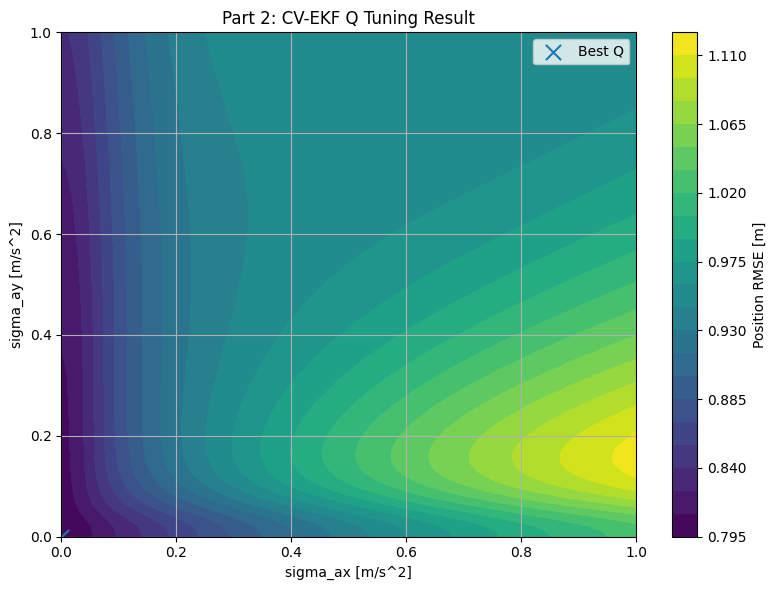

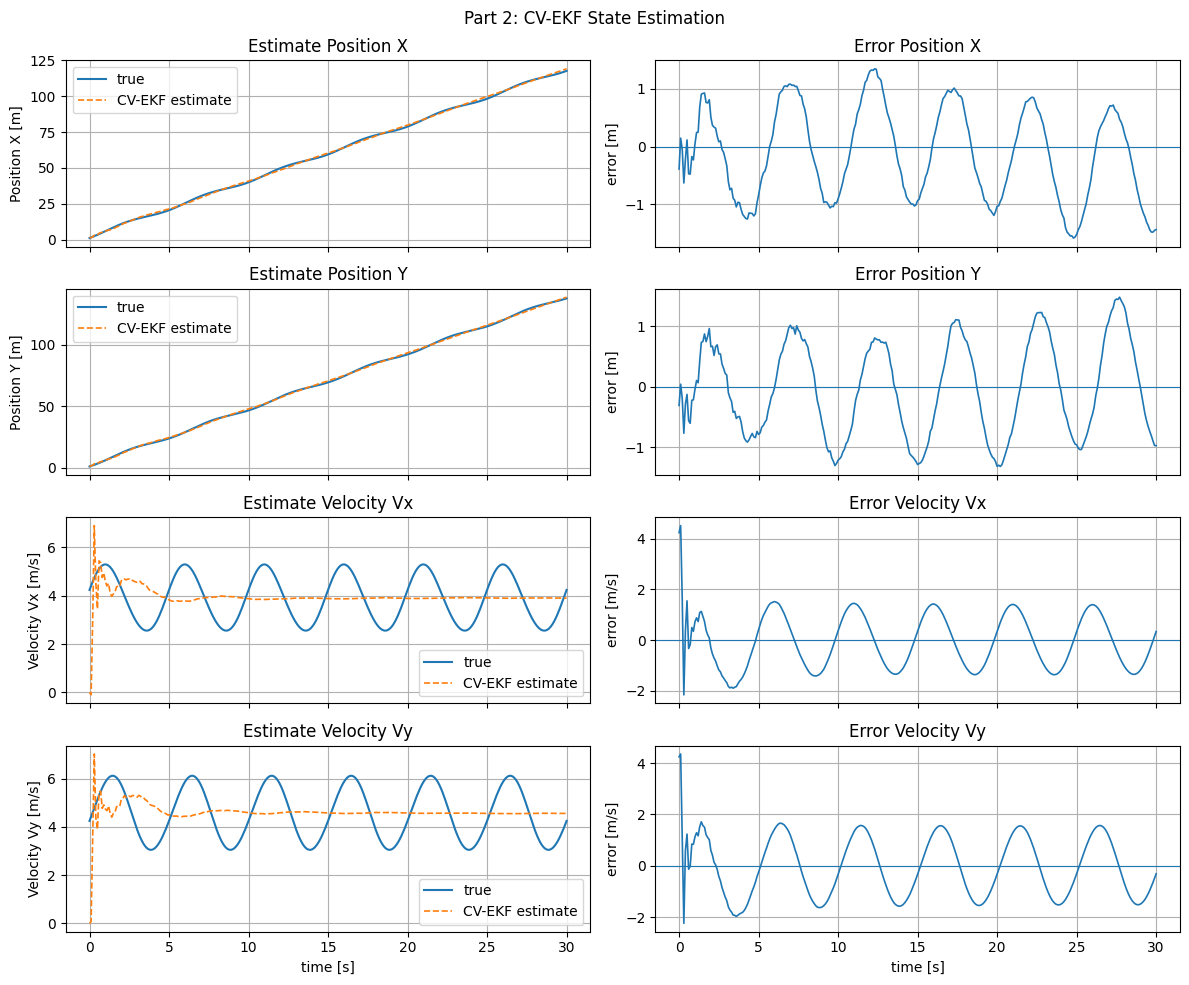

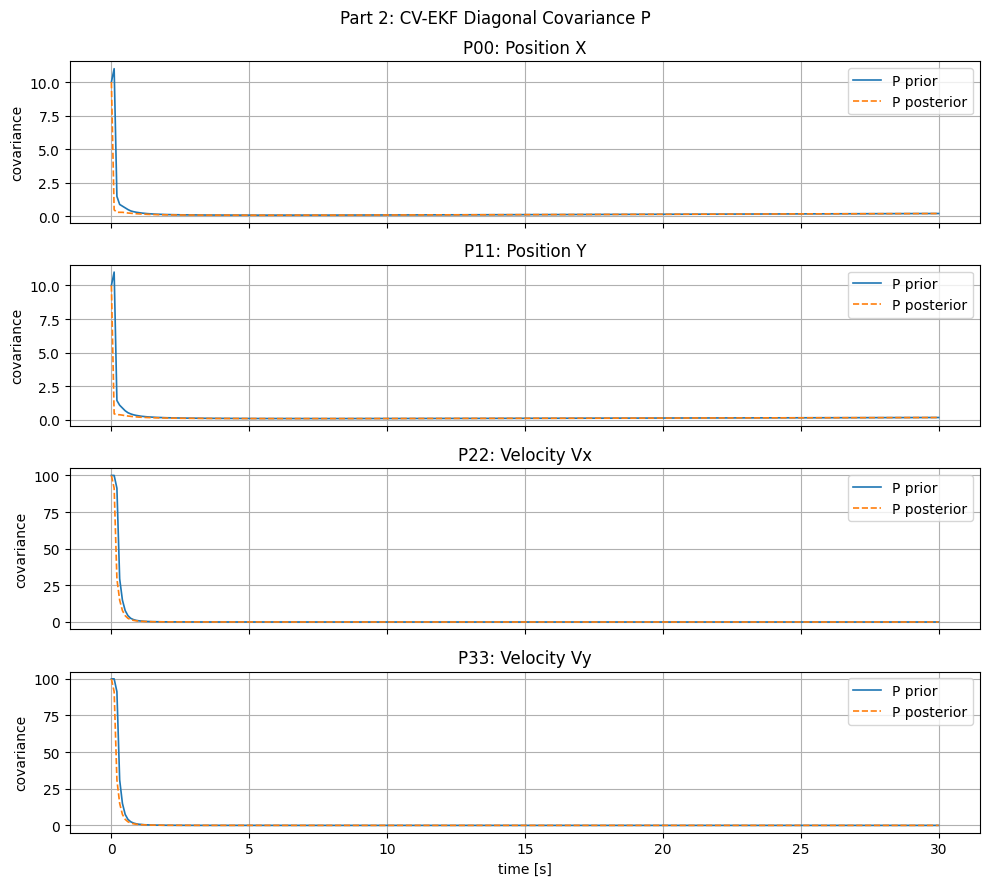

In [4]:
# ============================================================
# Practice 6 - Part 2
# CV-EKF with Best Q Tuning
# ============================================================


# ============================================================
# 1️⃣ CV Model 정의
#    State = [x, y, vx, vy]^T
# ============================================================

F_cv = np.array([
    [1.0, 0.0, dT,  0.0],
    [0.0, 1.0, 0.0, dT ],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0]
])

I_4 = np.eye(4)


# ============================================================
# 2️⃣ CV Measurement Function
#    h(x) = [r, theta]^T
# ============================================================

def h_cv(state):
    x = state[0]
    y = state[1]

    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    return np.array([r, theta])


# ============================================================
# 3️⃣ CV Measurement Jacobian
# ============================================================

def H_jacobian_cv(state):
    x = state[0]
    y = state[1]

    r2 = x**2 + y**2
    eps = 1e-8

    if r2 < eps:
        r2 = eps

    r = np.sqrt(r2)

    H = np.array([
        [ x / r,    y / r,    0.0, 0.0],
        [-y / r2,   x / r2,   0.0, 0.0]
    ])

    return H


# ============================================================
# 4️⃣ CV Q Matrix 생성
#    sigma_ax, sigma_ay 기반
# ============================================================

def make_Q_cv(sigma_ax, sigma_ay):
    Q = np.array([
        [dT**4 / 4.0 * sigma_ax**2, 0.0,                         dT**3 / 2.0 * sigma_ax**2, 0.0],
        [0.0,                          dT**4 / 4.0 * sigma_ay**2, 0.0,                         dT**3 / 2.0 * sigma_ay**2],
        [dT**3 / 2.0 * sigma_ax**2, 0.0,                         dT**2       * sigma_ax**2, 0.0],
        [0.0,                          dT**3 / 2.0 * sigma_ay**2, 0.0,                         dT**2       * sigma_ay**2]
    ])

    return Q


# ============================================================
# 5️⃣ R Matrix
# ============================================================

R = np.array([
    [sigma_r**2,      0.0],
    [0.0,             sigma_theta**2]
])


# ============================================================
# 6️⃣ True State for CV 비교용
# ============================================================

vx_true = V * np.cos(x_history[:, 2])
vy_true = V * np.sin(x_history[:, 2])

true_states_cv = np.column_stack([
    x_history[:, 0],
    x_history[:, 1],
    vx_true,
    vy_true
])


# ============================================================
# 7️⃣ CV-EKF 실행 함수
# ============================================================

def run_cv_ekf(sigma_ax, sigma_ay, return_history=True):
    Q = make_Q_cv(sigma_ax, sigma_ay)

    # 첫 번째 measurement로 초기 위치 설정
    r0 = y_history[0, 0]
    theta0 = y_history[0, 1]

    x0 = r0 * np.cos(theta0)
    y0 = r0 * np.sin(theta0)

    x_hat = np.array([x0, y0, 0.0, 0.0])

    P = np.diag([10.0, 10.0, 100.0, 100.0])

    x_hat_history = np.zeros((N, 4))
    P_prior_history = np.zeros((N, 4, 4))
    P_post_history = np.zeros((N, 4, 4))

    x_hat_history[0] = x_hat
    P_prior_history[0] = P
    P_post_history[0] = P

    for k in range(1, N):
        # -----------------------------
        # Prediction
        # -----------------------------
        x_pred = F_cv @ x_hat
        P_pred = F_cv @ P @ F_cv.T + Q

        # -----------------------------
        # Update
        # -----------------------------
        z_k = y_history[k]

        z_pred = h_cv(x_pred)
        H_k = H_jacobian_cv(x_pred)

        innovation = z_k - z_pred
        innovation[1] = wrap_angle(innovation[1])

        S = H_k @ P_pred @ H_k.T + R

        # K = P H^T S^{-1}
        K = np.linalg.solve(S, H_k @ P_pred).T

        x_hat = x_pred + K @ innovation

        P = (I_4 - K @ H_k) @ P_pred @ (I_4 - K @ H_k).T + K @ R @ K.T

        x_hat_history[k] = x_hat
        P_prior_history[k] = P_pred
        P_post_history[k] = P

    rmse_state = np.sqrt(np.mean((true_states_cv - x_hat_history)**2, axis=0))
    rmse_position = np.sqrt((rmse_state[0]**2 + rmse_state[1]**2) / 2.0)

    if return_history:
        return x_hat_history, P_prior_history, P_post_history, rmse_state, rmse_position
    else:
        return rmse_position


# ============================================================
# 8️⃣ CV-EKF Q Grid Search
# ============================================================

sigma_ax_list = np.round(np.arange(0.0, 1.0 + 0.01, 0.01), 4)
sigma_ay_list = np.round(np.arange(0.0, 1.0 + 0.01, 0.01), 4)

RMSE_grid_cv = np.zeros((len(sigma_ax_list), len(sigma_ay_list)))

print("=" * 60)
print("Part 2 CV-EKF Q Tuning Start")
print("=" * 60)

for i, sigma_ax in enumerate(sigma_ax_list):
    for j, sigma_ay in enumerate(sigma_ay_list):
        RMSE_grid_cv[i, j] = run_cv_ekf(
            sigma_ax=sigma_ax,
            sigma_ay=sigma_ay,
            return_history=False
        )

print("=" * 60)
print("Part 2 CV-EKF Q Tuning Finished")
print("=" * 60)


# ============================================================
# 9️⃣ Best Q 선택
# ============================================================

min_idx = np.argmin(RMSE_grid_cv)
best_i_cv, best_j_cv = np.unravel_index(min_idx, RMSE_grid_cv.shape)

best_sigma_ax = sigma_ax_list[best_i_cv]
best_sigma_ay = sigma_ay_list[best_j_cv]
best_rmse_pos_cv = RMSE_grid_cv[best_i_cv, best_j_cv]

print("=" * 60)
print("Part 2 CV-EKF Best Q Result")
print("=" * 60)
print(f"Best sigma_ax      = {best_sigma_ax:.4f} m/s^2")
print(f"Best sigma_ay      = {best_sigma_ay:.4f} m/s^2")
print(f"Best Position RMSE = {best_rmse_pos_cv:.6f} m")
print("=" * 60)


# ============================================================
# 🔟 Best Q로 CV-EKF 재실행
# ============================================================

x_hat_cv, P_prior_cv, P_post_cv, rmse_cv, rmse_pos_cv = run_cv_ekf(
    sigma_ax=best_sigma_ax,
    sigma_ay=best_sigma_ay,
    return_history=True
)

labels_cv = ["Position X", "Position Y", "Velocity Vx", "Velocity Vy"]
units_cv = ["m", "m", "m/s", "m/s"]

print("=" * 60)
print("Part 2 CV-EKF RMSE")
print("=" * 60)

for i in range(4):
    print(f"RMSE {labels_cv[i]:14s}: {rmse_cv[i]:.6f} {units_cv[i]}")

print(f"Position RMSE: {rmse_pos_cv:.6f} m")
print("=" * 60)


# ============================================================
# 1️⃣1️⃣ CV Q Tuning Plot
# ============================================================

SIGMA_AX, SIGMA_AY = np.meshgrid(sigma_ax_list, sigma_ay_list, indexing="ij")

plt.figure(figsize=(8, 6))
contour = plt.contourf(SIGMA_AX, SIGMA_AY, RMSE_grid_cv, levels=30)
plt.colorbar(contour, label="Position RMSE [m]")
plt.scatter(best_sigma_ax, best_sigma_ay, marker="x", s=120, label="Best Q")
plt.title("Part 2: CV-EKF Q Tuning Result")
plt.xlabel("sigma_ax [m/s^2]")
plt.ylabel("sigma_ay [m/s^2]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 1️⃣2️⃣ CV-EKF State Estimate Plot
# ============================================================

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)

for i in range(4):
    axes[i, 0].plot(t, true_states_cv[:, i], label="true", linewidth=1.5)
    axes[i, 0].plot(t, x_hat_cv[:, i], "--", label="CV-EKF estimate", linewidth=1.2)
    axes[i, 0].set_title(f"Estimate {labels_cv[i]}")
    axes[i, 0].set_ylabel(f"{labels_cv[i]} [{units_cv[i]}]")
    axes[i, 0].grid(True)
    axes[i, 0].legend()

    error = true_states_cv[:, i] - x_hat_cv[:, i]
    axes[i, 1].plot(t, error, linewidth=1.2)
    axes[i, 1].axhline(0.0, linewidth=0.8)
    axes[i, 1].set_title(f"Error {labels_cv[i]}")
    axes[i, 1].set_ylabel(f"error [{units_cv[i]}]")
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel("time [s]")
axes[-1, 1].set_xlabel("time [s]")

plt.suptitle("Part 2: CV-EKF State Estimation")
plt.tight_layout()
plt.show()


# ============================================================
# 1️⃣3️⃣ CV-EKF P00, P11, P22, P33 Plot
# ============================================================

P_diag_labels_cv = [
    "P00: Position X",
    "P11: Position Y",
    "P22: Velocity Vx",
    "P33: Velocity Vy"
]

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

for i in range(4):
    axes[i].plot(t, P_prior_cv[:, i, i], label="P prior", linewidth=1.2)
    axes[i].plot(t, P_post_cv[:, i, i], "--", label="P posterior", linewidth=1.2)
    axes[i].set_title(P_diag_labels_cv[i])
    axes[i].set_ylabel("covariance")
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel("time [s]")

plt.suptitle("Part 2: CV-EKF Diagonal Covariance P")
plt.tight_layout()
plt.show()

Part 3 DR-EKF Q Tuning Start
Part 3 DR-EKF Q Tuning Finished
Part 3 DR-EKF Best Q Result
Best sigma_V        = 0.0100 m/s
Best sigma_psidot   = 0.0010 rad/s
Best Position RMSE  = 0.240993 m
Part 3 DR-EKF RMSE
RMSE Position X    : 0.261976 m
RMSE Position Y    : 0.217999 m
RMSE Heading Psi   : 0.006941 rad
Heading RMSE         : 0.397714 deg
Position RMSE        : 0.240993 m


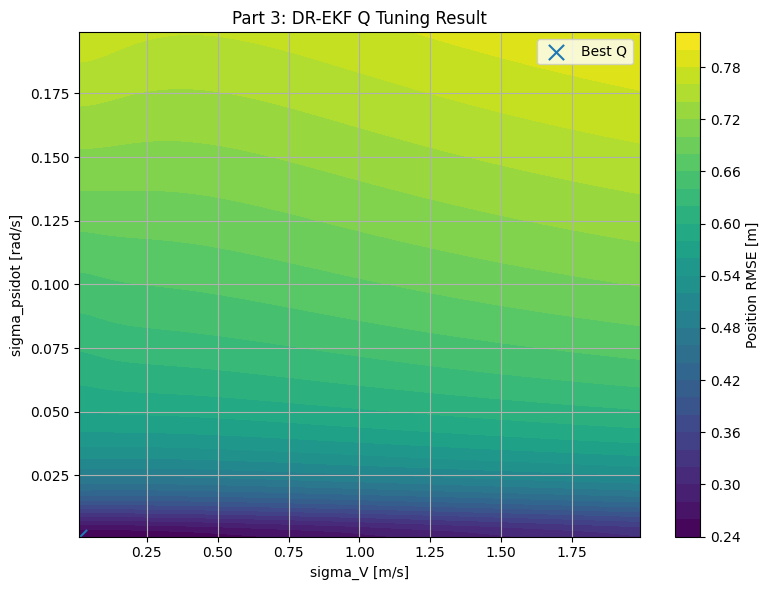

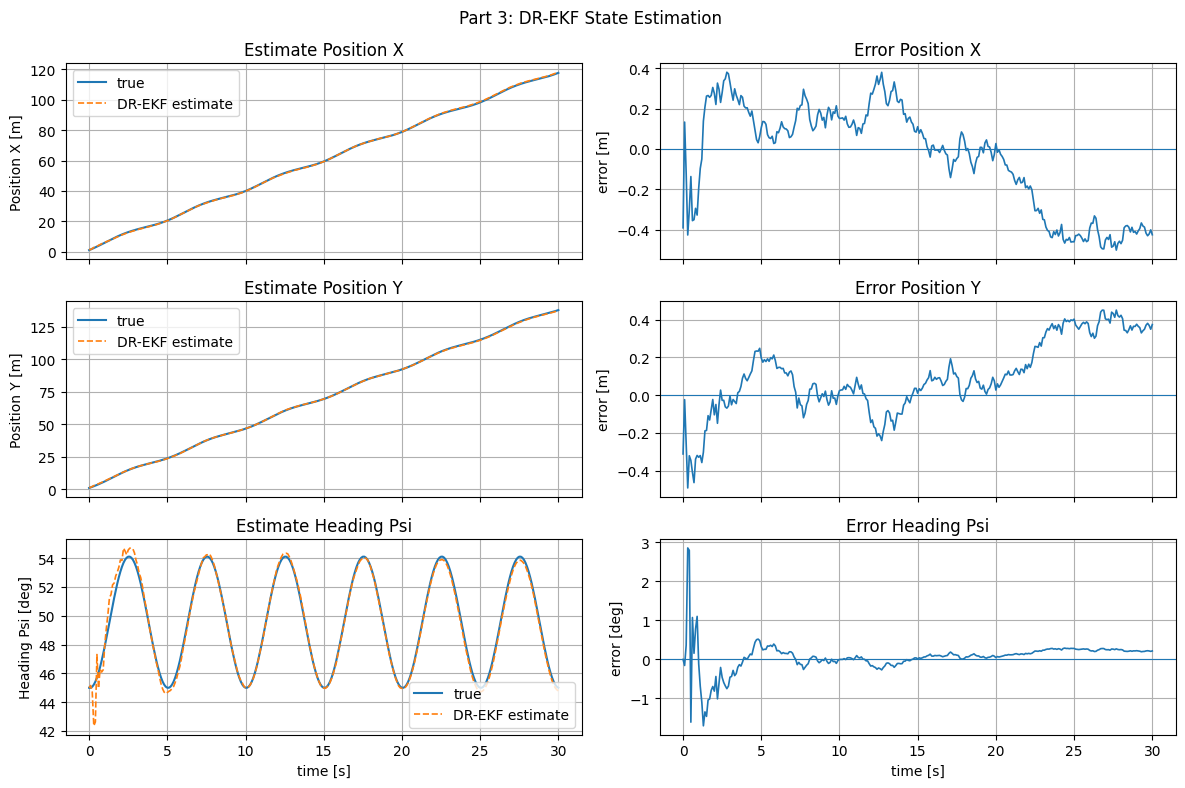

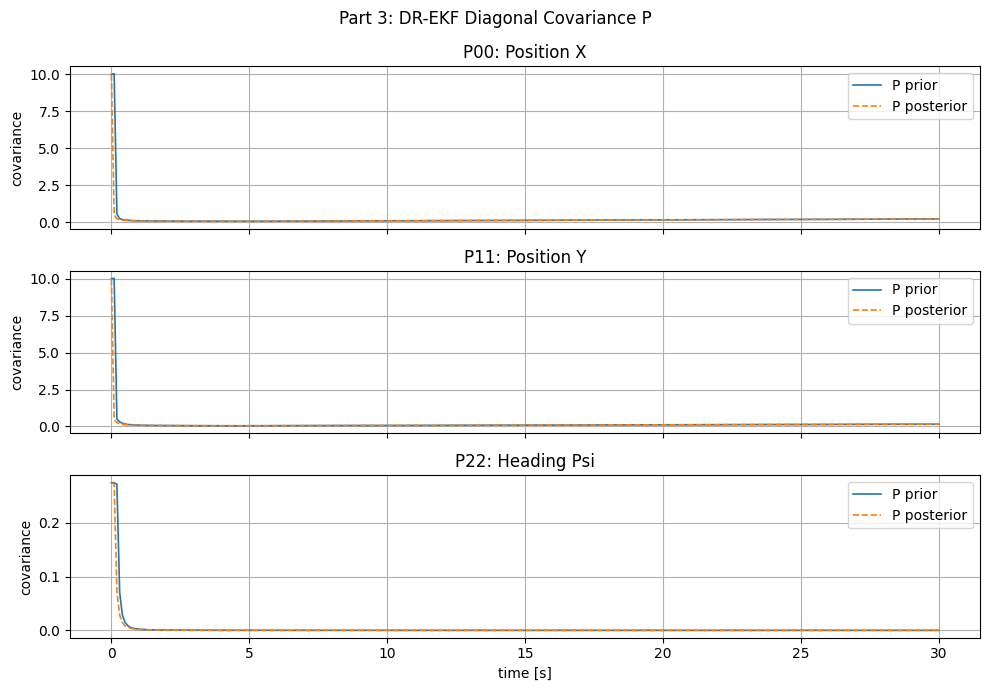

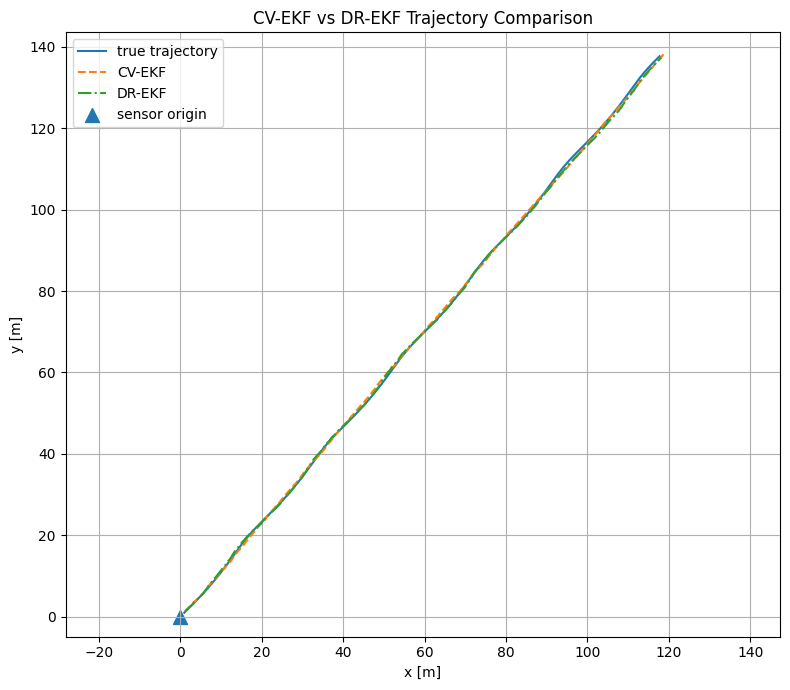

Final Comparison
CV-EKF Position RMSE : 0.798013 m
DR-EKF Position RMSE : 0.240993 m


In [5]:
# ============================================================
# Practice 6 - Part 3
# DR-EKF with Best Q Tuning
# ============================================================


# ============================================================
# 1️⃣ DR Process Model
#    State = [x, y, psi]^T
#    Input = [V, psi_dot]^T
# ============================================================

def f_dr(state, u):
    x = state[0]
    y = state[1]
    psi = state[2]

    V_k = u[0]
    psi_dot_k = u[1]

    x_next = x + V_k * dT * np.cos(psi)
    y_next = y + V_k * dT * np.sin(psi)
    psi_next = wrap_angle(psi + psi_dot_k * dT)

    return np.array([x_next, y_next, psi_next])


# ============================================================
# 2️⃣ DR System Jacobian F = df/dx
# ============================================================

def F_jacobian_dr(state, u):
    psi = state[2]
    V_k = u[0]

    F = np.array([
        [1.0, 0.0, -V_k * dT * np.sin(psi)],
        [0.0, 1.0,  V_k * dT * np.cos(psi)],
        [0.0, 0.0,  1.0]
    ])

    return F


# ============================================================
# 3️⃣ DR Input Jacobian G = df/du
#    u = [V, psi_dot]^T
# ============================================================

def G_jacobian_dr(state):
    psi = state[2]

    G = np.array([
        [dT * np.cos(psi), 0.0],
        [dT * np.sin(psi), 0.0],
        [0.0,              dT]
    ])

    return G


# ============================================================
# 4️⃣ DR Measurement Function
# ============================================================

def h_dr(state):
    x = state[0]
    y = state[1]

    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    return np.array([r, theta])


# ============================================================
# 5️⃣ DR Measurement Jacobian H = dh/dx
# ============================================================

def H_jacobian_dr(state):
    x = state[0]
    y = state[1]

    r2 = x**2 + y**2
    eps = 1e-8

    if r2 < eps:
        r2 = eps

    r = np.sqrt(r2)

    H = np.array([
        [ x / r,    y / r,    0.0],
        [-y / r2,   x / r2,   0.0]
    ])

    return H


# ============================================================
# 6️⃣ DR Q 생성
#    입력 노이즈 Q_u = diag(sigma_V^2, sigma_psidot^2)
#    Q_k = G_k Q_u G_k^T
# ============================================================

def make_Q_dr(state, sigma_V, sigma_psidot):
    G = G_jacobian_dr(state)

    Q_u = np.diag([
        sigma_V**2,
        sigma_psidot**2
    ])

    Q = G @ Q_u @ G.T

    return Q


# ============================================================
# 7️⃣ True State for DR 비교용
# ============================================================

true_states_dr = x_history.copy()


# ============================================================
# 8️⃣ DR-EKF 실행 함수
# ============================================================

def run_dr_ekf(sigma_V, sigma_psidot, return_history=True):
    # 첫 번째 measurement로 초기 위치 설정
    r0 = y_history[0, 0]
    theta0 = y_history[0, 1]

    x0 = r0 * np.cos(theta0)
    y0 = r0 * np.sin(theta0)

    # 문제 조건의 초기 heading 사용
    psi0 = np.deg2rad(45.0)

    x_hat = np.array([x0, y0, psi0])

    P = np.diag([
        10.0,
        10.0,
        np.deg2rad(30.0)**2
    ])

    I_3 = np.eye(3)

    x_hat_history = np.zeros((N, 3))
    P_prior_history = np.zeros((N, 3, 3))
    P_post_history = np.zeros((N, 3, 3))

    x_hat_history[0] = x_hat
    P_prior_history[0] = P
    P_post_history[0] = P

    for k in range(1, N):
        u_prev = np.array([
            V[k - 1],
            psi_dot[k - 1]
        ])

        # -----------------------------
        # Prediction
        # -----------------------------
        F_k = F_jacobian_dr(x_hat, u_prev)
        Q_k = make_Q_dr(x_hat, sigma_V, sigma_psidot)

        x_pred = f_dr(x_hat, u_prev)
        P_pred = F_k @ P @ F_k.T + Q_k

        # -----------------------------
        # Update
        # -----------------------------
        z_k = y_history[k]

        z_pred = h_dr(x_pred)
        H_k = H_jacobian_dr(x_pred)

        innovation = z_k - z_pred
        innovation[1] = wrap_angle(innovation[1])

        S = H_k @ P_pred @ H_k.T + R

        K = np.linalg.solve(S, H_k @ P_pred).T

        x_hat = x_pred + K @ innovation
        x_hat[2] = wrap_angle(x_hat[2])

        P = (I_3 - K @ H_k) @ P_pred @ (I_3 - K @ H_k).T + K @ R @ K.T

        x_hat_history[k] = x_hat
        P_prior_history[k] = P_pred
        P_post_history[k] = P

    error = true_states_dr - x_hat_history
    error[:, 2] = np.array([wrap_angle(e) for e in error[:, 2]])

    rmse_state = np.sqrt(np.mean(error**2, axis=0))
    rmse_position = np.sqrt((rmse_state[0]**2 + rmse_state[1]**2) / 2.0)

    if return_history:
        return x_hat_history, P_prior_history, P_post_history, rmse_state, rmse_position
    else:
        return rmse_position


# ============================================================
# 9️⃣ DR-EKF Q Grid Search
#    sigma_V, sigma_psidot 탐색
# ============================================================

sigma_V_list = np.round(np.arange(0.01, 2.00 + 0.01, 0.02), 4)
sigma_psidot_list = np.round(np.arange(0.001, 0.200 + 0.001, 0.002), 4)

RMSE_grid_dr = np.zeros((len(sigma_V_list), len(sigma_psidot_list)))

print("=" * 60)
print("Part 3 DR-EKF Q Tuning Start")
print("=" * 60)

for i, sigma_V in enumerate(sigma_V_list):
    for j, sigma_psidot in enumerate(sigma_psidot_list):
        RMSE_grid_dr[i, j] = run_dr_ekf(
            sigma_V=sigma_V,
            sigma_psidot=sigma_psidot,
            return_history=False
        )

print("=" * 60)
print("Part 3 DR-EKF Q Tuning Finished")
print("=" * 60)


# ============================================================
# 🔟 Best Q 선택
# ============================================================

min_idx = np.argmin(RMSE_grid_dr)
best_i_dr, best_j_dr = np.unravel_index(min_idx, RMSE_grid_dr.shape)

best_sigma_V = sigma_V_list[best_i_dr]
best_sigma_psidot = sigma_psidot_list[best_j_dr]
best_rmse_pos_dr = RMSE_grid_dr[best_i_dr, best_j_dr]

print("=" * 60)
print("Part 3 DR-EKF Best Q Result")
print("=" * 60)
print(f"Best sigma_V        = {best_sigma_V:.4f} m/s")
print(f"Best sigma_psidot   = {best_sigma_psidot:.4f} rad/s")
print(f"Best Position RMSE  = {best_rmse_pos_dr:.6f} m")
print("=" * 60)


# ============================================================
# 1️⃣1️⃣ Best Q로 DR-EKF 재실행
# ============================================================

x_hat_dr, P_prior_dr, P_post_dr, rmse_dr, rmse_pos_dr = run_dr_ekf(
    sigma_V=best_sigma_V,
    sigma_psidot=best_sigma_psidot,
    return_history=True
)

labels_dr = ["Position X", "Position Y", "Heading Psi"]
units_dr = ["m", "m", "rad"]

print("=" * 60)
print("Part 3 DR-EKF RMSE")
print("=" * 60)

for i in range(3):
    print(f"RMSE {labels_dr[i]:14s}: {rmse_dr[i]:.6f} {units_dr[i]}")

print(f"Heading RMSE         : {np.rad2deg(rmse_dr[2]):.6f} deg")
print(f"Position RMSE        : {rmse_pos_dr:.6f} m")
print("=" * 60)


# ============================================================
# 1️⃣2️⃣ DR Q Tuning Plot
# ============================================================

SIGMA_V, SIGMA_PSIDOT = np.meshgrid(sigma_V_list, sigma_psidot_list, indexing="ij")

plt.figure(figsize=(8, 6))
contour = plt.contourf(SIGMA_V, SIGMA_PSIDOT, RMSE_grid_dr, levels=30)
plt.colorbar(contour, label="Position RMSE [m]")
plt.scatter(best_sigma_V, best_sigma_psidot, marker="x", s=120, label="Best Q")
plt.title("Part 3: DR-EKF Q Tuning Result")
plt.xlabel("sigma_V [m/s]")
plt.ylabel("sigma_psidot [rad/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 1️⃣3️⃣ DR-EKF State Estimate Plot
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

for i in range(3):
    if i == 2:
        true_plot = np.rad2deg(true_states_dr[:, i])
        est_plot = np.rad2deg(x_hat_dr[:, i])
        error_plot = np.rad2deg(np.array([
            wrap_angle(true_states_dr[k, i] - x_hat_dr[k, i]) for k in range(N)
        ]))
        unit_label = "deg"
    else:
        true_plot = true_states_dr[:, i]
        est_plot = x_hat_dr[:, i]
        error_plot = true_plot - est_plot
        unit_label = "m"

    axes[i, 0].plot(t, true_plot, label="true", linewidth=1.5)
    axes[i, 0].plot(t, est_plot, "--", label="DR-EKF estimate", linewidth=1.2)
    axes[i, 0].set_title(f"Estimate {labels_dr[i]}")
    axes[i, 0].set_ylabel(f"{labels_dr[i]} [{unit_label}]")
    axes[i, 0].grid(True)
    axes[i, 0].legend()

    axes[i, 1].plot(t, error_plot, linewidth=1.2)
    axes[i, 1].axhline(0.0, linewidth=0.8)
    axes[i, 1].set_title(f"Error {labels_dr[i]}")
    axes[i, 1].set_ylabel(f"error [{unit_label}]")
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel("time [s]")
axes[-1, 1].set_xlabel("time [s]")

plt.suptitle("Part 3: DR-EKF State Estimation")
plt.tight_layout()
plt.show()


# ============================================================
# 1️⃣4️⃣ DR-EKF P00, P11, P22 Plot
# ============================================================

P_diag_labels_dr = [
    "P00: Position X",
    "P11: Position Y",
    "P22: Heading Psi"
]

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for i in range(3):
    axes[i].plot(t, P_prior_dr[:, i, i], label="P prior", linewidth=1.2)
    axes[i].plot(t, P_post_dr[:, i, i], "--", label="P posterior", linewidth=1.2)
    axes[i].set_title(P_diag_labels_dr[i])
    axes[i].set_ylabel("covariance")
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel("time [s]")

plt.suptitle("Part 3: DR-EKF Diagonal Covariance P")
plt.tight_layout()
plt.show()


# ============================================================
# 1️⃣5️⃣ CV-EKF vs DR-EKF 비교
# ============================================================

plt.figure(figsize=(8, 7))
plt.plot(x_history[:, 0], x_history[:, 1], label="true trajectory", linewidth=1.5)
plt.plot(x_hat_cv[:, 0], x_hat_cv[:, 1], "--", label="CV-EKF", linewidth=1.5)
plt.plot(x_hat_dr[:, 0], x_hat_dr[:, 1], "-.", label="DR-EKF", linewidth=1.5)
plt.scatter(0.0, 0.0, marker="^", s=100, label="sensor origin")
plt.title("CV-EKF vs DR-EKF Trajectory Comparison")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


print("=" * 60)
print("Final Comparison")
print("=" * 60)
print(f"CV-EKF Position RMSE : {rmse_pos_cv:.6f} m")
print(f"DR-EKF Position RMSE : {rmse_pos_dr:.6f} m")
print("=" * 60)